<a href="https://colab.research.google.com/github/ElormPatamia/Car-Prediction/blob/main/PatamiaElorm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

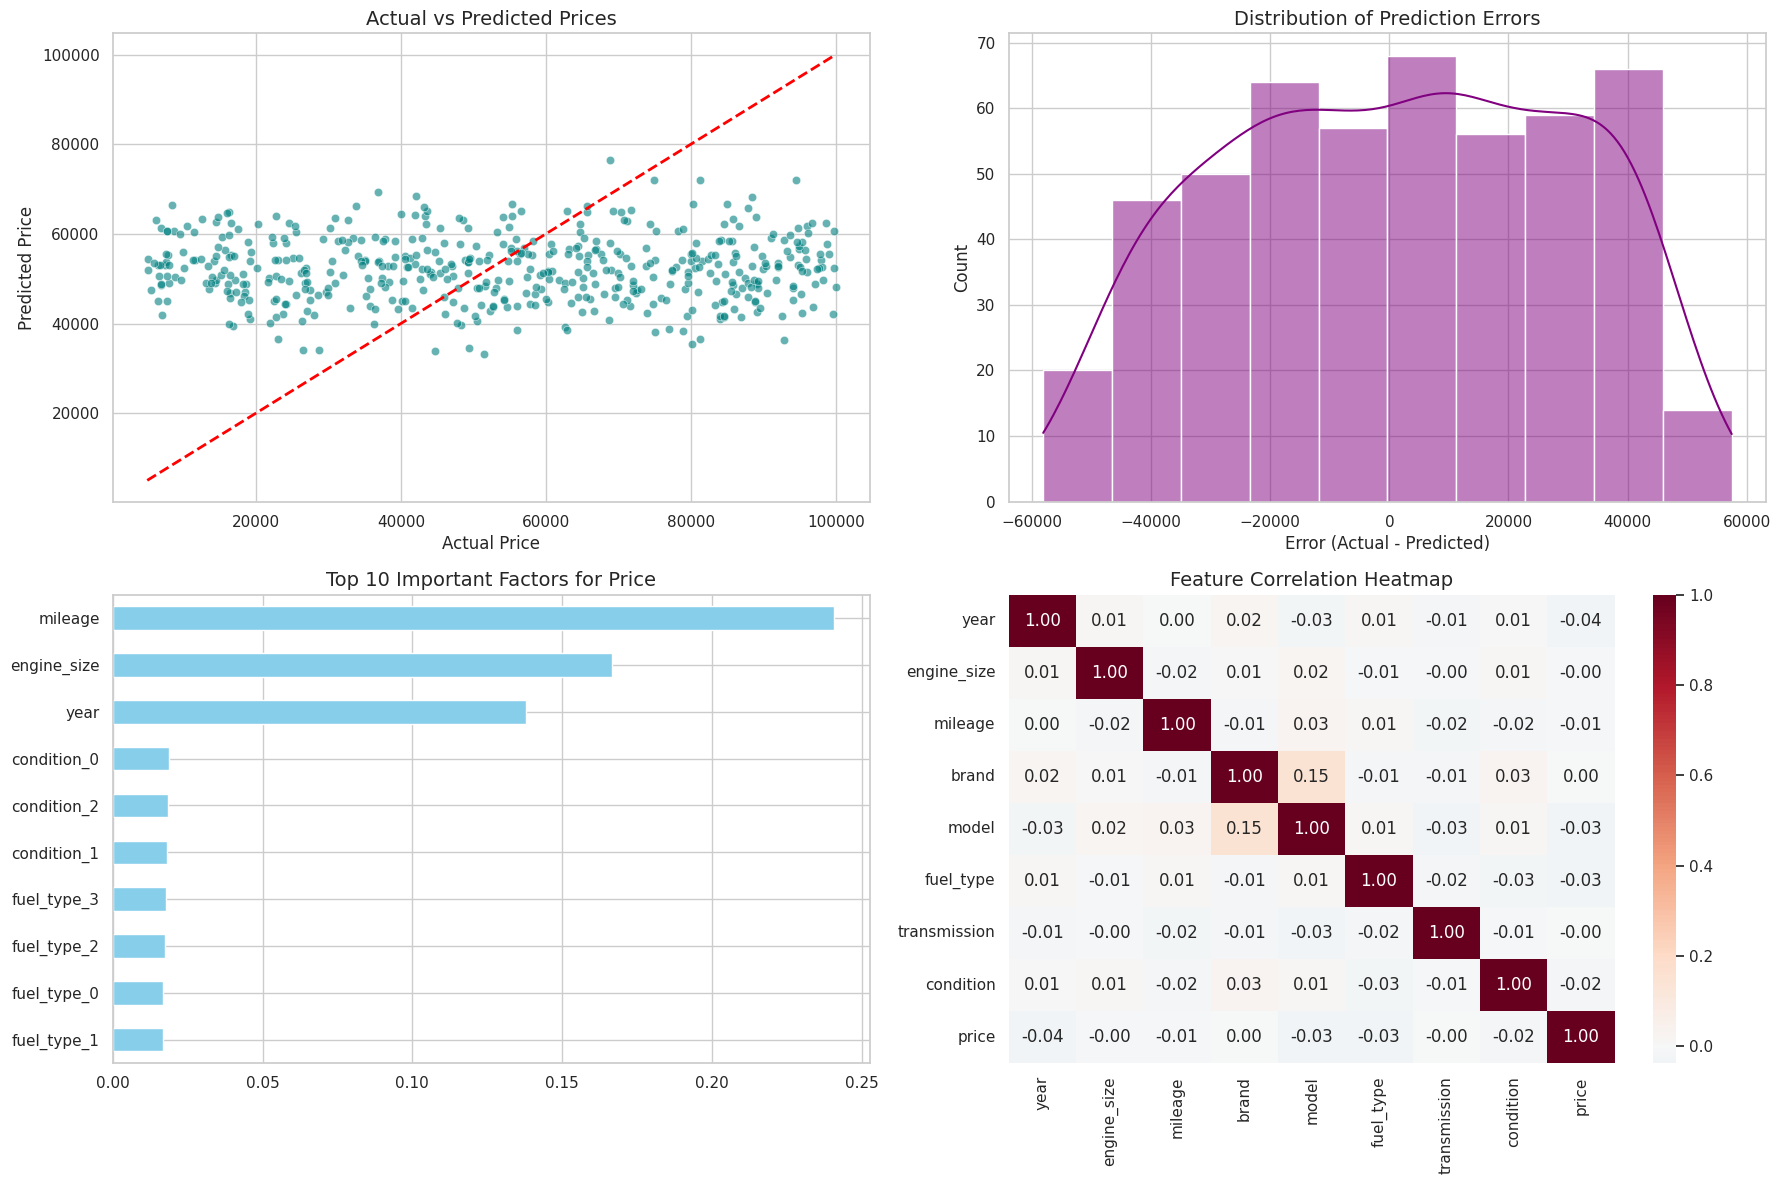

✅ Libraries imported successfully!


In [16]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# 1. Load data
df = pd.read_csv('car_price_convert.csv')

# 2. Define features and target
X = df.drop('price', axis=1)
y = df['price']

# 3. Preprocessing
categorical_features = ['brand', 'model', 'fuel_type', 'transmission', 'condition']
numeric_features = ['year', 'engine_size', 'mileage']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 4. Model Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# --- VISUALIZATIONS ---

# Set a clean style for all plots
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 12))

# Plot 1: Actual vs Predicted
plt.subplot(2, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--')
plt.title('Actual vs Predicted Prices', fontsize=14)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

# Plot 2: Distribution of Errors (Residuals)
plt.subplot(2, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution of Prediction Errors', fontsize=14)
plt.xlabel('Error (Actual - Predicted)')

# Plot 3: Top 10 Feature Importances
plt.subplot(2, 2, 3)
ohe = model.named_steps['preprocessor'].named_transformers_['cat']
feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))
importances = model.named_steps['regressor'].feature_importances_
feat_importances = pd.Series(importances, index=feature_names)
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 10 Important Factors for Price', fontsize=14)

# Plot 4: Correlation Heatmap
plt.subplot(2, 2, 4)
sns.heatmap(df.corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully!')